<a href="https://colab.research.google.com/github/801-Hillside-Terrace/SMART-2026/blob/main/week2/Week2_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Topics: Ridge Regression, Generalization, Regularization, Train/Validation/Test Split, Cross Validation

In [1]:
#imports
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import csv

# set seed for consistency
torch.manual_seed(801)

Recall that for the typical linear regression setup:
1. Our data is $\{y_i,x_{i1},...,x_{ip}\}_{i=1}^n$.
2. Our model is $\hat{y}=\beta_0+\beta_1x_{i1}+...+\beta_px_{ip}$.
3. Our loss is MSE: $\mathcal{L} = \frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2$.
4. We can use the closed form solution or gradient descent for optimization.

Have the true data generating process be $y_i=0.05+0.01x_i+0.02x_i^2+ϵ$ where $\epsilon \sim N(0,0.01^2)$.

In [2]:
# generate data based on true model (true data generating process):

num_train = 5 # 5 training
num_val = 500 # 500 validation
n = num_train + num_val # total

noise = torch.randn(n,1) * 0.01 # epsilon N(0,0.01^2)
x = torch.randn(n,1) # randomly generate x as N(0,1)s
x2 = x ** 2 # x squared
X = torch.cat((x,x2),1) # x matrix
y = 0.05 + 0.01*x + 0.02*x2 + noise # generate y by the true model

shuffled_indices = torch.randperm(n) # shuffle indices to split into train-val
train_indices = shuffled_indices[:num_train] # 5 train indices
val_indices = shuffled_indices[num_train:] # 500 val indices
X_train = X[train_indices] # training set for X
y_train = y[train_indices] # training set for y
X_val = X[val_indices] # validation set for X
y_val = y[val_indices] # validation set for y

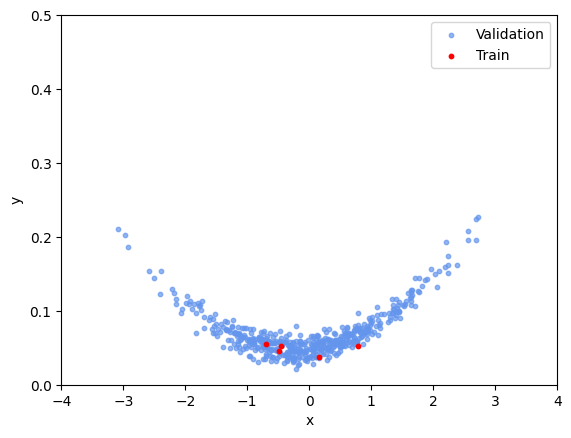

In [3]:
# plot
plt.scatter(X_val[:,0], y_val,color = 'cornflowerblue', marker = 'o', s = 10, alpha = 0.7, label = 'Validation')
plt.scatter(X_train[:,0], y_train,color = 'red', marker = 'o', s = 10, label = 'Train')
plt.legend()
plt.xlim(-4,4)
plt.ylim(0,0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Now let's fit a heavily over-parameterized model (degree 4 polynomial):

$\hat{y}_i=\beta_0+\sum_{k=1}^{4}\beta_kx_{i}^k=\beta_0+\beta_1x_i+\beta_2x_i^2+\beta_3x_i^3+\beta_{4}x_i^{4}$


In [4]:
# create tensors of all 4 powers:
X_train_4 = torch.zeros(num_train,4)
for k in range(4):
  X_train_4[:,k] = X_train[:,0] ** (k+1)

X_val_4 = torch.zeros(num_val,4)
for k in range(4):
  X_val_4[:,k] = X_val[:,0] ** (k+1)

# specify model, loss function, and optimizer
overparam_model = nn.Linear(in_features = 4, out_features = 1) # model (4 input features, single output (predict y))
criterion = nn.MSELoss() # MSE loss
optimizer = torch.optim.SGD(overparam_model.parameters(), lr = 0.05) # gradient descent optimizer

# to store losses over time for plotting:
train_losses = []
val_losses = []

# train model
num_epochs = 100
for epoch in range(num_epochs):
  #settings
  overparam_model.train()
  optimizer.zero_grad()
  # forward pass
  y_hat = overparam_model(X_train_4) # predicted
  loss = criterion(y_hat, y_train) # loss
  train_losses.append(loss.item()) # track all losses
  # backward pass
  loss.backward()
  optimizer.step()
  # evaluate on validation:
  overparam_model.eval()
  with torch.no_grad():
    y_hat_val = overparam_model(X_val_4)
    val_loss = criterion(y_hat_val, y_val)
    val_losses.append(val_loss.item()) # track all val losses


  if (epoch + 1) % 10 == 0:
    print(f'Epoch {epoch + 1:2d} | Train Loss = {loss.item():.4f} | Val Loss = {val_loss.item():.4f}')


Epoch 10 | Train Loss = 0.0398 | Val Loss = 0.2369
Epoch 20 | Train Loss = 0.0108 | Val Loss = 0.3301
Epoch 30 | Train Loss = 0.0045 | Val Loss = 0.3617
Epoch 40 | Train Loss = 0.0021 | Val Loss = 0.3746
Epoch 50 | Train Loss = 0.0011 | Val Loss = 0.3829
Epoch 60 | Train Loss = 0.0006 | Val Loss = 0.3888
Epoch 70 | Train Loss = 0.0004 | Val Loss = 0.3923
Epoch 80 | Train Loss = 0.0002 | Val Loss = 0.3934
Epoch 90 | Train Loss = 0.0002 | Val Loss = 0.3927
Epoch 100 | Train Loss = 0.0002 | Val Loss = 0.3904


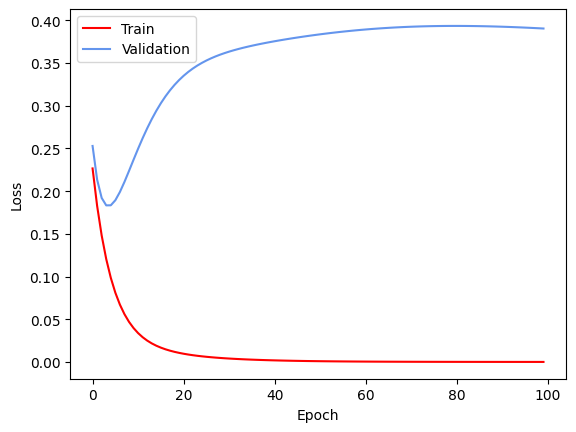

In [5]:
# plot the losses over time
plt.plot(range(num_epochs), train_losses, color = 'red', label = 'Train')
plt.plot(range(num_epochs), val_losses, color = 'cornflowerblue', label = 'Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Note how the training loss quickly converged to $0$, but the validation loss increases/stays significantly higher.  

We can also check the closed form solution values:

In [6]:
# compute closed form betas/losses
X = torch.cat((torch.ones(num_train, 1),X_train_4),1)
Xv = torch.cat((torch.ones(num_val, 1),X_val_4),1)
beta = torch.linalg.solve(X.T @ X, X.T @ y_train)
print('Closed form solution Train MSE: ', torch.mean((X @ beta - y_train)** 2))
print('Closed form solution Validation MSE: ', torch.mean((Xv @ beta - y_val)** 2))

Closed form solution Train MSE:  tensor(1.1803e-12)
Closed form solution Validation MSE:  tensor(111.6183)


This is an extreme case of over-fitting (validation loss >>> training loss).

The plot makes it very clear what's happening here:

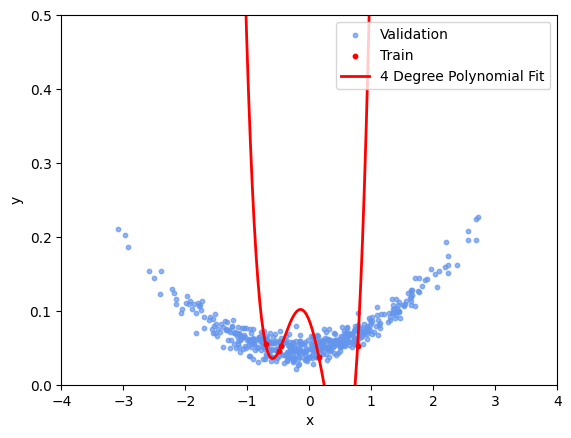

In [7]:
# plotting
x_plot = torch.linspace(-3, 3, 200).unsqueeze(1)
X_plot_4 = torch.stack([x_plot[:,0]**(k+1) for k in range(4)], dim=1)
y_plot = torch.cat((torch.ones(X_plot_4.shape[0], 1), X_plot_4),1) @ beta

plt.scatter(Xv[:,1], y_val,color = 'cornflowerblue', marker = 'o', s = 10, alpha = 0.7, label = 'Validation')
plt.scatter(X[:,1], y_train,color = 'red', marker = 'o', s = 10, label = 'Train')
plt.plot(x_plot.numpy(), y_plot.numpy(), label="4 Degree Polynomial Fit", linewidth=2, color = 'red')
plt.xlim(-4,4)
plt.ylim(0,0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Now we will swap a single datapoint between train and validation, to show how this generates an entirely different model:

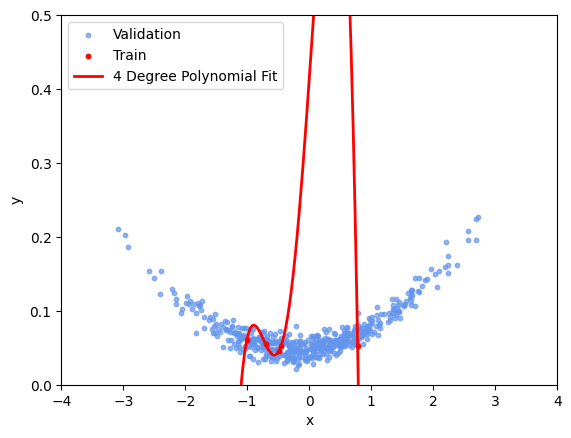

In [8]:
X_train_swap = X_train_4.clone()
y_train_swap = y_train.clone()
X_val_swap = X_val_4.clone()
y_val_swap = y_val.clone()

# swap point
y_train_swap[0] = y_val[0]
y_val_swap[0] = y_train[0]
X_train_swap[0] = X_val_4[0]
X_val_swap[0] = X_train_4[0]

# re-fit with closed-form
X_swap = torch.cat((torch.ones(num_train, 1),X_train_swap),1)
Xv_swap = torch.cat((torch.ones(num_val, 1),X_val_swap),1)
beta_swap = torch.linalg.solve(X_swap.T @ X_swap, X_swap.T @ y_train_swap)

# plotting
x_plot = torch.linspace(-3, 3, 200).unsqueeze(1)
X_plot_4 = torch.cat((torch.ones(x_plot.shape[0],1),torch.stack([x_plot[:,0]**(k+1) for k in range(4)], dim=1)), 1)
y_plot = X_plot_4 @ beta_swap

plt.scatter(Xv_swap[:,1], y_val_swap,color = 'cornflowerblue', marker = 'o', s = 10, alpha = 0.7, label = 'Validation')
plt.scatter(X_swap[:,1], y_train_swap,color = 'red', marker = 'o', s = 10, label = 'Train')
plt.plot(x_plot.numpy(), y_plot.numpy(), label="4 Degree Polynomial Fit", linewidth=2, color = 'red')
plt.xlim(-4,4)
plt.ylim(0,0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


We see that a significantly different model has been generated.  This is an extreme case of overfitting, and some of the issues are further exaggerated since we chose such a small training size, but hopefully this can help you see how an overly complex model can easily overfit as well as have high variance (slight changes in the training set produce significant changes in the model/parameters since the model can heavily adjust itself).

Now we use the same setup, but with Ridge loss.
$\mathcal{L}_{\text{Ridge}} = \frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2+\lambda \sum_{j=1}^p\beta_j^2$.

Ridge is a form of regularization.  Regularization typically refers to loss function modifications that incentivize the model to be simpler/avoid learning noise in order to generalize better. In this case we are imposing a penalty on the weights/coefficients to prevent them from being too large.  In ML, this type of strategy is generally called weight decay.  Note that instead of squaring the weights in the loss we could have instead included a penalty on the absolute value of the weights (this is called LASSO) or similar.  Generally, regularization increases model bias to some degree but reduces model variance.  The variance reduction is typically more significant and more important for prediction purposes.  When using weight decay we should also rescale the features so they are on a similar scale, else parameters that are large because of a features units will be unfairly penalized.

In [9]:
# standardize features
train_mean = X_train_4.mean(dim=0, keepdim=True) # get mean
train_std  = X_train_4.std(dim=0, keepdim=True) + 1e-8 # get std and add a small term so that we don't divide by machine 0
X_train_4_scaled = (X_train_4 - train_mean) / train_std # subtract mean, divide by std
X_val_4_scaled   = (X_val_4 - train_mean) / train_std # we do the same thing to the validation set since the model is fit on that scale

# specify model, loss function, and optimizer
overparam_model_ridge = nn.Linear(in_features = 4, out_features = 1) # model (4 input features, single output (predict y))
criterion = nn.MSELoss() # MSE loss
optimizer = torch.optim.SGD(overparam_model_ridge.parameters(), lr = 0.05) # gradient descent optimizer
lmbda = 1 # set lambda = 1


# to store losses over time for plotting:
train_losses = []
val_losses = []


# train model
num_epochs = 100
for epoch in range(num_epochs):
  #settings
  overparam_model_ridge.train()
  optimizer.zero_grad()
  # forward pass
  y_hat = overparam_model_ridge(X_train_4_scaled) # predicted
  loss = criterion(y_hat, y_train) +  (lmbda * torch.sum(overparam_model_ridge.weight ** 2)) # MSE loss + weight penalty
  train_losses.append(loss.item()) # track all losses
  # backward pass
  loss.backward()
  optimizer.step()
  # evaluate on validation:
  overparam_model_ridge.eval()
  with torch.no_grad():
    y_hat_val = overparam_model_ridge(X_val_4_scaled)
    val_loss = criterion(y_hat_val, y_val)
    val_losses.append(val_loss.item()) # track all val losses


  if (epoch + 1) % 10 == 0:
    print(f'Epoch {epoch + 1:2d} | Train Loss = {loss.item():.4f} | Val Loss = {val_loss.item():.4f}')

Epoch 10 | Train Loss = 0.0288 | Val Loss = 23.9103
Epoch 20 | Train Loss = 0.0035 | Val Loss = 2.6639
Epoch 30 | Train Loss = 0.0004 | Val Loss = 0.3710
Epoch 40 | Train Loss = 0.0001 | Val Loss = 0.0693
Epoch 50 | Train Loss = 0.0000 | Val Loss = 0.0209
Epoch 60 | Train Loss = 0.0000 | Val Loss = 0.0108
Epoch 70 | Train Loss = 0.0000 | Val Loss = 0.0080
Epoch 80 | Train Loss = 0.0000 | Val Loss = 0.0072
Epoch 90 | Train Loss = 0.0000 | Val Loss = 0.0069
Epoch 100 | Train Loss = 0.0000 | Val Loss = 0.0068


Both losses decreased this time.  Note that the training loss here includes the penalty, while the validation loss is just MSE.

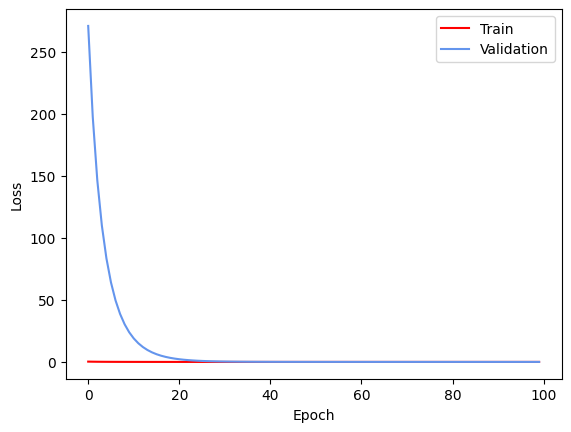

In [10]:
# plot the losses over time
plt.plot(range(num_epochs), train_losses, color = 'red', label = 'Train')
plt.plot(range(num_epochs), val_losses, color = 'cornflowerblue', label = 'Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

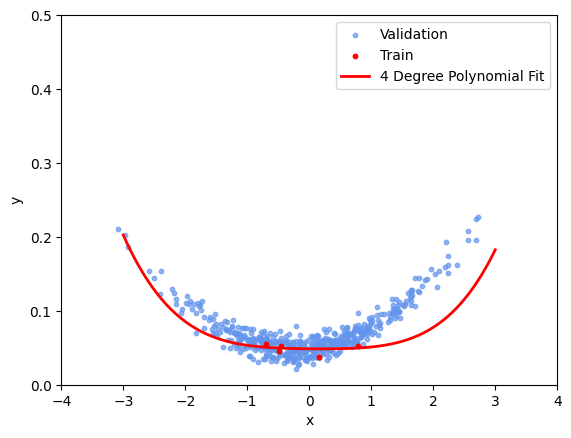

In [11]:
# plotting
weights = overparam_model_ridge.weight.detach().flatten()
bias = overparam_model_ridge.bias.detach()
beta_ridge = torch.cat([bias, weights])

x_plot = torch.linspace(-3, 3, 200).unsqueeze(1)
X_plot_4 = torch.stack([x_plot[:,0]**(k+1) for k in range(4)], dim=1)
y_plot = torch.cat((torch.ones(X_plot_4.shape[0], 1), X_plot_4),1) @ beta_ridge

plt.scatter(Xv[:,1], y_val,color = 'cornflowerblue', marker = 'o', s = 10, alpha = 0.7, label = 'Validation')
plt.scatter(X[:,1], y_train,color = 'red', marker = 'o', s = 10, label = 'Train')
plt.plot(x_plot.numpy(), y_plot.numpy(), label="4 Degree Polynomial Fit", linewidth=2, color = 'red')
plt.xlim(-4,4)
plt.ylim(0,0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

See that adding the penalty was enough to make the model significantly more behaved.  This model still does not seem great, but it is significantly better (and keep in mind we are limited by the 5 data points and still have a misspecified model as the true model is quadratic).  It should also be clear that this setup results in less model variance, if I swapped a data point this time I would expect a fairly similar model (though the small amount of training points remains an issue).

A question you may have is how to select the penalty strength: $\lambda$.  

In practice, the most straightforward way to select $\lambda$ is to set aside some amount of your training data (typically about 20%) to be validation data.  You then fit models with varying $\lambda$ values on the remaining 80% and see their performance on the validation data.  

For example, maybe I want to try $\lambda=0.25$ and $\lambda = 0.5$.  I take my entire test data, say it is 100 observations for simplicity, and I randomly hold aside 20 of them for validation.  I then fit the model with $\lambda=0.25$ on the 80 remaining and fit the model with $\lambda=0.5$ on the same 80.  I then evaluate the performance of each model on the 20 in the validation set that I held out.  I pick the $\lambda$ that performs best on the validation set.

Another method is known as cross-validation.  This is where instead of doing one train-validation split I do multiple, and the validation sets do not overlap.  So if I do 5 splits (5-fold cross-validation), I first set 80% of my data to train and 20% to validate.  I fit my model on the 80% and see its performance on the 20% validation.  I then repeat this 4 more times, but the 5 validation sets are all entirely unique.  Finally I average the 5 validation performances.

<img src='https://zitaoshen.rbind.io/project/machine_learning/machine-learning-101-cross-vaildation/featured.png' width = 400>

Conceptual Questions:

1. What will an underfit model typically look like in terms of train and validation loss?
2. What will an overfit model typically look like in terms of train and validation loss?
3. What tends to happen to training error as model complexity increases?
4. What tends to happen to validation/test error as model complexity increases?
5. How does ridge penalizing the large weights improve model generalization?
6. Why is training error not enough to gauge how well a model can generalize?
7. Why might a simple model tend to generalize better than a complex one?
8. Why does high model variance tend to imply that a model will generalize poorly?
9. Why does ridge increase the model bias (relative to linear regression with MSE)?
10. What happens if we make $\lambda$ too large?
11. Why might ridge be a better method than trying to add/drop features?
12. How can ridge help even in cases where the model is correctly specified?
13. If a complex model and simple model have similar training error (assume validation/test error is unknown) why would we typically prefer the simpler one?